In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip freeze > '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/xgboost_energia_eolica_requirements.txt'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import joblib
import numpy as np
import folium

In [ ]:
# --- Etapa 1: Carregando e Preparando os Dados ---
print("--- Etapa 1: Preparação dos Dados para Regressão Eólica ---")
try:
    df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/FACT_LOCALIDADE_CLIMA_202509272358.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'FACT_LOCALIDADE_CLIMA_202509272358.csv' não encontrado.")
    exit()
df_train.columns = [col.replace('"', '').lower() for col in df_train.columns]
df_train.dropna(inplace=True)
print("Preparação dos dados de treino.")

--- Etapa 1: Preparação dos Dados para Regressão Eólica ---
Preparação dos dados de treino.


In [ ]:
# --- Etapa 2: Treinamento do Modelo com XGBoost ---
print("\n--- Iniciando Etapa 2: Treinamento do Modelo com XGBoost ---")
target = 'wind_speed_10m_mean'
features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'surface_pressure_mean', 'shortwave_radiation_sum',
    'precipitation_sum'
]

X = df_train[features]
y = df_train[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nIniciando o treinamento do modelo XGBoost...")
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
model_xgb.fit(X_train, y_train)
print("Treinamento finalizado.")


y_pred = model_xgb.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nResultados da Avaliação do Modelo:")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {np.sqrt(mse):.4f}")


--- Iniciando Etapa 2: Treinamento do Modelo com XGBoost ---

Iniciando o treinamento do modelo XGBoost...
Treinamento finalizado.

Resultados da Avaliação do Modelo:
R² (Coeficiente de Determinação): 0.6504
MSE (Erro Quadrático Médio): 12.7994
RMSE (Raiz do Erro Quadrático Médio): 3.5776


In [ ]:
# ---  Etapa 3: Salvando o modelo ---
print("\n--- Iniciando Etapa 3: Salvando o Modelo ---")
model_filename_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/xgboost_regressor_eolico.joblib'
joblib.dump(model_xgb, model_filename_xgb)
print(f"Modelo XGBoost salvo em: {model_filename_xgb}")


--- Iniciando Etapa 3: Salvando o Modelo ---
Modelo XGBoost salvo em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/xgboost_regressor_eolico.joblib


In [ ]:
# --- Etapa 4: Prever Potencial EOLICA para Goiás com XGBoost ---
print("\n--- Inicio Etapa 4: Previsão para Goiás com modelo XGBoost ---")
try:
    df_goias = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/goias_clima_era5_diario_completo.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'goias_clima_era5_diario_completo.csv' não encontrado.")
    exit()
if df_goias[features].isnull().sum().any():
    df_goias.dropna(subset=features, inplace=True)

X_goias = df_goias[features]
loaded_model_xgb = joblib.load(model_filename_xgb)
df_goias['VELOCIDADE_VENTO_PREDITA_XGB'] = loaded_model_xgb.predict(X_goias)
results_filename_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/previsoes_eolico_goias_xgb.csv'
df_goias.to_csv(results_filename_xgb, index=False)
print(f"Previsões salvas em: {results_filename_xgb}")



--- Inicio Etapa 4: Previsão para Goiás com modelo XGBoost ---
Previsões salvas em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/previsoes_eolico_goias_xgb.csv


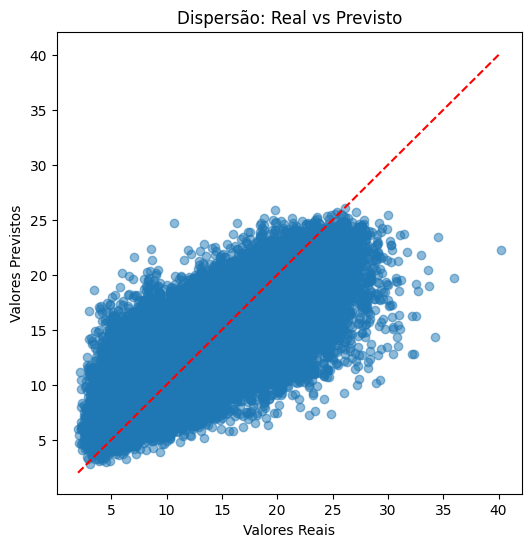

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Real vs Previsto')
plt.show()

In [ ]:
# ---    ---
print("\n--- Iniciando Etapa 5: Gerando o Mapa ---")
potencial_eolico_xgb = df_goias.groupby('municipio').agg(
    vento_medio_predito=('VELOCIDADE_VENTO_PREDITA_XGB', 'mean'),
    lat=('lat', 'first'),
    lon=('lon', 'first')
).reset_index()
top_municipios_eolico_xgb = potencial_eolico_xgb.sort_values(by='vento_medio_predito', ascending=False).head(10)

mapa_goias_eolico_xgb = folium.Map(location=[-15.98, -49.86], zoom_start=7, tiles='OpenStreetMap')

for index, row in top_municipios_eolico_xgb.iterrows():
    popup_text = f"<b>Município:</b> {row['municipio']}<br><b>Vento Médio (XGB):</b> {row['vento_medio_predito']:.2f} m/s"

    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=folium.Tooltip(
            text=row['municipio'],
            permanent=True,
            direction='top',
            offset=[0, -10],
            style="font-weight:bold; font-size:10px;"
        )
    ).add_to(mapa_goias_eolico_xgb)

mapa_filename_eolico_xgb = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/mapa_potencial_eolico_xgb.html'
mapa_goias_eolico_xgb.save(mapa_filename_eolico_xgb)
print(f"\nMapa salvo como '{mapa_filename_eolico_xgb}'. O mapa será exibido abaixo.")

mapa_goias_eolico_xgb


--- Iniciando Etapa 5: Gerando o Mapa ---

Mapa salvo como '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/9.xgbost/arquivos_gerados/mapa_potencial_eolico_xgb.html'. O mapa será exibido abaixo.
